<a href="https://colab.research.google.com/github/Santiago-1505/Laboratorio-3-Imagenes/blob/main/lab3_imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 3 — Clasificación de Residuos con CoAtNet
## Dataset: Garbage Classification v2

---

## Estructura del notebook

| Sección | Descripción | Puntaje |
|---------|-------------|---------|
| **Punto 1** | Explicación detallada de cada capa de CoAtNet | 40% |
| **Punto 2** | Implementación completa con resultados y presentación | 60% |

---

**Red seleccionada:** CoAtNet<br>
**Dataset:** Garbage Classification v2 — 10 clases, ~13.348 imágenes  
**Framework:** PyTorch + timm  


# **Integrantes**
- Ricardo Medina Herrerra
- Santiago Villegas Naranjo

# **Punto #1: <br>  Explicar cada capa de la red seleccionada. (CoAtNet)**

# Capa S0: Convolution Stem

La primera etapa de CoAtNet recibe la imagen de entrada y tiene como objetivo realizar una extracción inicial de características visuales mientras reduce el tamaño espacial de la imagen para disminuir el costo computacional de las etapas posteriores. Según la arquitectura presentada en el paper, esta etapa está compuesta por dos capas convolucionales de tamaño 3×3, donde la primera utiliza un stride de 2 para realizar un proceso de downsampling o reducción de resolución. Esto permite que una imagen de entrada de 224×224 píxeles pase a una representación de aproximadamente 112×112 píxeles.

El propósito principal de esta etapa es capturar información visual básica presente en la imagen. Durante esta fase, la red aprende patrones simples como bordes horizontales y verticales, esquinas, cambios de intensidad lumínica, contrastes de color y texturas elementales. Estas características son fundamentales porque constituyen los bloques de construcción que serán utilizados por las capas posteriores para identificar patrones más complejos.

Los autores justifican el uso de convoluciones al inicio de la arquitectura debido a que los mecanismos de atención global presentan una complejidad computacional cuadrática respecto al tamaño espacial de la imagen. Aplicar atención directamente sobre una imagen de alta resolución generaría un costo computacional extremadamente elevado. Por esta razón, la arquitectura utiliza inicialmente operaciones convolucionales que son eficientes para procesar información local y reducir gradualmente el tamaño de la representación visual.

Además, esta etapa aporta una de las propiedades más importantes de las redes convolucionales: el sesgo inductivo o inductive bias. Gracias a este sesgo, la red posee una capacidad natural para detectar patrones locales independientemente de su ubicación exacta dentro de la imagen, lo que favorece la generalización cuando se dispone de cantidades limitadas de datos de entrenamiento.

---

# Capa S1: MBConv

Después del Convolution Stem aparece la primera etapa basada en bloques MBConv. Los autores establecen que esta etapa siempre debe utilizar convoluciones debido a que el tamaño espacial de la representación todavía es demasiado grande para aplicar mecanismos de atención global de forma eficiente.

MBConv significa Mobile Inverted Bottleneck Convolution, una estructura introducida inicialmente en MobileNetV2 y posteriormente utilizada en EfficientNet. Este bloque fue seleccionado porque posee una estructura muy similar a la utilizada por los Transformers modernos. Tanto MBConv como los bloques Transformer emplean una estrategia conocida como inverted bottleneck, donde primero se expande el número de canales para aumentar la capacidad de representación y posteriormente se reduce nuevamente para permitir conexiones residuales eficientes.

La función principal de esta etapa es continuar procesando características locales mientras incrementa gradualmente la complejidad semántica de la información extraída. Si en el Stem la red detectaba bordes y texturas simples, en S1 comienza a reconocer combinaciones de estos patrones que pueden representar fragmentos de objetos, curvas, formas geométricas y estructuras visuales más elaboradas.

Los autores demostraron que mantener bloques convolucionales en las primeras etapas mejora significativamente la capacidad de generalización del modelo. Esto se debe a que las convoluciones poseen una fuerte propiedad de equivariancia traslacional, lo que permite que los mismos patrones sean reconocidos independientemente de la posición donde aparezcan dentro de la imagen.

---

# Subcapa de Expansión 1×1 dentro de MBConv

El primer componente interno de un bloque MBConv es una convolución 1×1 encargada de expandir el número de canales. En CoAtNet se utiliza un factor de expansión igual a 4. Esto significa que si la entrada posee 96 canales, la representación interna pasa temporalmente a 384 canales.

Esta expansión tiene como objetivo aumentar la capacidad de representación de la red antes de realizar el procesamiento espacial. Al incrementar la dimensionalidad de los datos, la red dispone de un espacio más amplio para aprender combinaciones complejas de características visuales.

Desde una perspectiva conceptual, esta operación puede entenderse como una proyección de la información hacia un espacio de características más rico donde es posible modelar relaciones más complejas entre los diferentes patrones detectados previamente.

---

# Subcapa Depthwise Convolution 3×3

Después de la expansión se aplica una operación conocida como Depthwise Convolution. Esta capa constituye uno de los elementos fundamentales de CoAtNet porque representa el puente conceptual entre las redes convolucionales y los Transformers.

A diferencia de una convolución tradicional, donde cada filtro interactúa simultáneamente con todos los canales de entrada, la Depthwise Convolution procesa cada canal de manera independiente utilizando un filtro específico para dicho canal. Esto reduce considerablemente el número de parámetros y operaciones requeridas.

Matemáticamente, los autores muestran que la Depthwise Convolution puede expresarse como una suma ponderada de valores pertenecientes a una vecindad local alrededor de cada píxel. Curiosamente, esta formulación es muy similar a la utilizada por los mecanismos de Self-Attention, donde también se calcula una suma ponderada de información proveniente de diferentes posiciones espaciales.

La diferencia principal radica en que la convolución utiliza pesos fijos aprendidos durante el entrenamiento, mientras que la atención calcula pesos dinámicos que dependen del contenido de la imagen. Esta observación fue uno de los descubrimientos clave del paper y permitió desarrollar la integración entre ambos paradigmas dentro de una misma arquitectura.

---

# Subcapa Squeeze-and-Excitation (SE)

Posteriormente se incorpora un bloque Squeeze-and-Excitation. Este mecanismo tiene la función de recalibrar dinámicamente la importancia de cada canal de características.

El proceso comienza realizando un resumen global de cada canal mediante una operación de pooling. Posteriormente, una pequeña red neuronal aprende qué canales contienen información más relevante para la tarea específica. Finalmente, se generan pesos que amplifican o reducen la contribución de cada canal antes de continuar el procesamiento.

En términos prácticos, si la red está analizando una imagen de una botella plástica, algunos canales pueden estar especializados en detectar bordes curvos, mientras que otros pueden responder a texturas particulares del plástico. El bloque SE permite asignar mayor importancia a aquellos canales que resulten más útiles para la clasificación final.

Los autores utilizan un factor de compresión de 0.25 para equilibrar capacidad representacional y eficiencia computacional.

---

# Subcapa de Proyección 1×1

Una vez finalizado el procesamiento interno del bloque MBConv, se aplica una segunda convolución 1×1 cuya función es reducir nuevamente la cantidad de canales al tamaño original.

Esta operación recibe la representación expandida y la proyecta hacia una dimensión menor. Gracias a esta reducción es posible mantener un consumo moderado de memoria y facilitar la implementación de conexiones residuales.

Desde el punto de vista matemático, esta capa actúa como un mecanismo de compresión que conserva la información más relevante obtenida durante la expansión y el procesamiento espacial.

---

# Conexión Residual

Cada bloque MBConv incorpora una conexión residual que suma la entrada original con la salida generada por el bloque.

Esta técnica fue introducida originalmente en ResNet y tiene como objetivo facilitar el entrenamiento de redes profundas. Al permitir que la información original fluya directamente hacia capas posteriores, se reduce el problema de desaparición del gradiente y se mejora significativamente la estabilidad del proceso de entrenamiento.

En CoAtNet, las conexiones residuales permiten que la red aprenda únicamente las transformaciones necesarias sobre la información de entrada en lugar de reconstruir completamente la representación desde cero en cada capa.

---

# Capa S2: MBConv Profundo

La etapa S2 continúa utilizando bloques MBConv, pero ahora con una mayor profundidad y una cantidad superior de canales. Esta etapa representa el último nivel puramente convolucional antes de la transición hacia los mecanismos de atención.

En esta fase la red ya no se limita a detectar patrones simples. Las representaciones comienzan a capturar partes significativas de objetos, estructuras geométricas complejas y configuraciones visuales que pueden corresponder a componentes específicos de las clases presentes en el conjunto de datos.

Los experimentos realizados por los autores demostraron que mantener esta etapa convolucional es fundamental para lograr una adecuada generalización. De hecho, los resultados muestran que reemplazar demasiadas capas convolucionales por mecanismos de atención produce una reducción en la capacidad de transferencia y en el desempeño sobre conjuntos de datos no vistos.

Esta observación llevó a los autores a concluir que las convoluciones son especialmente efectivas para procesar información visual de bajo nivel y nivel intermedio, mientras que la atención resulta más beneficiosa para modelar relaciones de alto nivel.

---

# Capa S3: Transformer con Relative Attention

La etapa S3 marca la transición desde el procesamiento basado en convoluciones hacia el procesamiento basado en atención.

Para este punto de la arquitectura, la resolución espacial ya ha sido reducida significativamente, permitiendo que los mecanismos de atención global puedan aplicarse de forma eficiente.

Cada bloque Transformer de CoAtNet está compuesto por dos módulos principales: Relative Self-Attention y Feed Forward Network. Ambos módulos están rodeados por conexiones residuales y normalización previa.

La misión de esta etapa es capturar relaciones de largo alcance entre diferentes regiones de la imagen. Mientras que las convoluciones procesan principalmente vecindades locales, la atención puede relacionar instantáneamente cualquier posición de la imagen con cualquier otra posición, independientemente de la distancia existente entre ellas.

Esto permite que la red comprenda la estructura global de los objetos y las relaciones contextuales presentes en la escena.

---

# Relative Self-Attention

La Relative Self-Attention constituye la innovación principal de CoAtNet.

Los autores observaron que los Transformers tradicionales poseen una gran capacidad de modelado, pero carecen de ciertos sesgos inductivos presentes en las CNN. Para solucionar este problema introducen un término de atención relativa que incorpora información sobre la distancia espacial entre posiciones.

En lugar de calcular la atención únicamente a partir de la similitud entre características visuales, CoAtNet añade un sesgo dependiente de la posición relativa entre los elementos que interactúan.

De esta manera, la atención final combina dos fuentes de información: el contenido visual de los elementos y la distancia espacial que los separa. Esto permite recuperar la propiedad de equivariancia traslacional característica de las convoluciones mientras se conserva la flexibilidad de la atención global.

Gracias a este mecanismo, la red puede reconocer un objeto aunque aparezca en diferentes posiciones dentro de la imagen y, al mismo tiempo, modelar relaciones complejas entre regiones distantes.

---

# Feed Forward Network (FFN)

Después del mecanismo de atención se aplica una Feed Forward Network.

Esta red consiste en una expansión del espacio de características seguida por una función de activación GELU y posteriormente una proyección de regreso al tamaño original.

La función principal del FFN es transformar la información agregada por la atención y producir representaciones más discriminativas. Mientras que la atención se encarga de recopilar información relevante de diferentes posiciones, el FFN procesa dicha información para generar características de mayor nivel semántico.

Esta combinación entre atención y transformación no lineal constituye uno de los elementos fundamentales de la arquitectura Transformer.

---

# Layer Normalization

Antes de cada módulo de atención y cada FFN se aplica Layer Normalization.

Los autores utilizan una estrategia conocida como Pre-Activation, donde la normalización se realiza antes de ejecutar cada operación principal. Esta decisión mejora la estabilidad numérica durante el entrenamiento y facilita la propagación del gradiente a través de arquitecturas profundas.

Layer Normalization también ayuda a reducir variaciones excesivas en la distribución de las activaciones, permitiendo una convergencia más rápida y estable.

---

# Capa S4: Transformer Final

La última etapa de CoAtNet está compuesta nuevamente por bloques Transformer con Relative Attention, pero trabajando sobre representaciones aún más compactas y con un mayor número de canales.

En este nivel, la red ya dispone de suficiente información para modelar conceptos semánticos completos. Las representaciones dejan de describir partes aisladas de los objetos y comienzan a capturar entidades completas.

Por ejemplo, en un problema de clasificación de residuos, esta etapa puede representar directamente conceptos como botella plástica, lata metálica, caja de cartón o recipiente de vidrio. La atención global permite integrar toda la información recopilada a lo largo de la red para construir una comprensión completa del contenido visual.

Debido a que la resolución espacial es muy reducida, el costo computacional de la atención global resulta manejable, permitiendo aprovechar plenamente la capacidad de modelado de los Transformers.

---

# Global Average Pooling

Una vez finalizada la etapa S4, la red aplica Global Average Pooling.

Esta operación toma todos los mapas de características producidos por la última capa y calcula el promedio de cada canal. Como resultado, una representación espacial tridimensional se transforma en un único vector de características.

El objetivo de esta operación es condensar toda la información aprendida en una representación compacta que describa la imagen completa.

A diferencia de Vision Transformer, CoAtNet no utiliza un token especial de clasificación. Los autores optan por Global Average Pooling debido a su simplicidad y eficiencia.

---

# Fully Connected Layer

La última capa de la arquitectura es una capa totalmente conectada o Fully Connected Layer.

Esta capa recibe el vector generado por Global Average Pooling y produce una puntuación para cada una de las clases del problema.

Durante el entrenamiento, la red aprende qué patrones presentes en el vector final están asociados con cada categoría. Durante la inferencia, estas puntuaciones son transformadas en probabilidades mediante una función Softmax.

La clase con la probabilidad más alta corresponde a la predicción final del modelo. De esta manera, toda la información extraída progresivamente desde bordes simples en el Stem hasta conceptos semánticos complejos en S4 se utiliza para realizar la clasificación definitiva de la imagen.

---
# **PUNTO 2** :<br> Implementar un ejemplo con la topología de red seleccionada y realizar una presentación.


## **Pipeline**:
1. Importación del dataset desde Kaggle
2. Exploración y análisis exploratorio (EDA)
3. Preprocesamiento y Data Augmentation
4. Carga del modelo CoAtNet preentrenado
5. Entrenamiento con scheduler y early stopping
6. Evaluación: accuracy, loss, matriz de confusión, reporte de clasificación
7. Visualización de predicciones
8. Conclusiones

---
## Paso 1 — Importación del Dataset desde Kaggle

Usamos `kagglehub` para descargar el dataset directamente en Colab. La versión `standardized_256` contiene imágenes ya redimensionadas a 256×256 píxeles, lo que acelera el preprocesamiento.

In [5]:
import kagglehub

# Descargar la última versión del dataset
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.


In [ ]:
# Verificar la estructura de carpetas del dataset
# El dataset tiene 3 versiones de imágenes:
#   - original: tamaños variables
#   - standardized_256: imágenes 256×256 (usaremos esta)
#   - standardized_384: imágenes 384×384
# Usamos standardized_256 porque CoAtNet espera 224×224 y es más rápido de cargar.

import os

# Listar carpetas disponibles en el dataset
print("Contenido del dataset:")
!ls {path}

print("\nClases en standardized_256:")
!ls {path+"/standardized_256"}

Contenido del dataset:
original  standardized_256  standardized_384

Clases en standardized_256:
battery     cardboard  glass  paper    shoes
biological  clothes    metal  plastic  trash


---
## Análisis Exploratorio de Datos


 Distribución del dataset:
   Total de clases : 10
   Total de imágenes: 12259
   Clase más grande: clothes (1892 imgs)
   Clase más pequeña: trash (453 imgs)
   Ratio desbalance: 4.2x



,Clase,Cantidad
0,clothes,1892
1,glass,1736
2,plastic,1597
3,shoes,1449
4,cardboard,1411
5,paper,1336
6,metal,930
7,battery,756
8,biological,699
9,trash,453


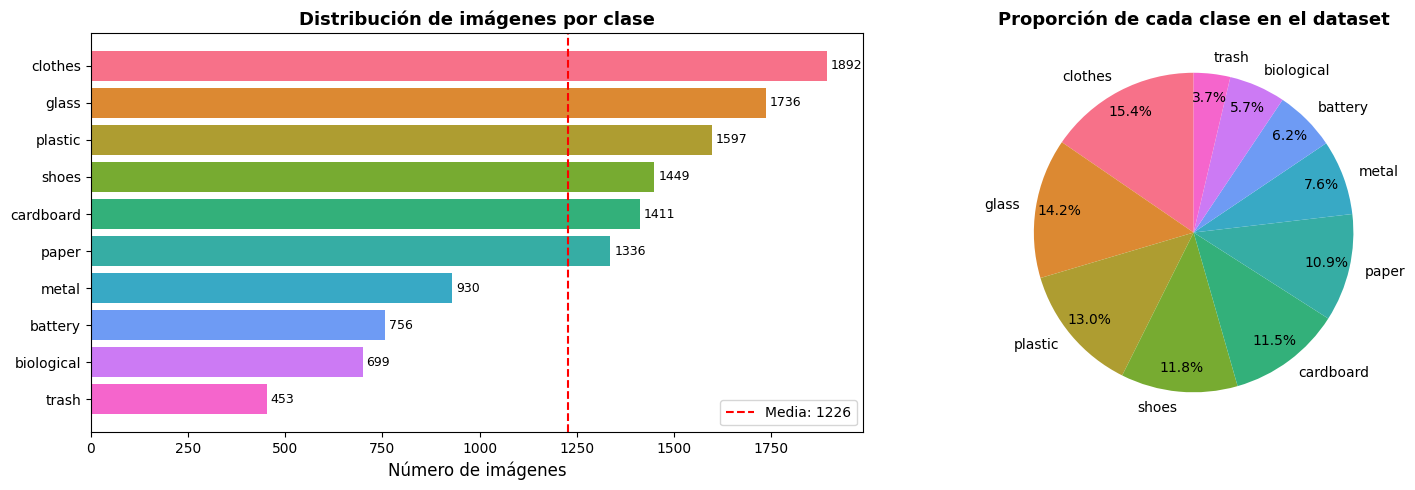

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Ruta a las imágenes estandarizadas de 256×256
data_dir = os.path.join(path, 'standardized_256')

# Obtener la lista de clases (subcarpetas) y contar imágenes en cada una
classes_raw = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

stats = []
for cls in classes_raw:
    count = len([f for f in os.listdir(os.path.join(data_dir, cls))
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
    stats.append({'Clase': cls, 'Cantidad': count})

# Crear DataFrame ordenado de mayor a menor cantidad
df_stats = pd.DataFrame(stats).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

print(f"\n Distribución del dataset:")
print(f"   Total de clases : {len(classes_raw)}")
print(f"   Total de imágenes: {df_stats['Cantidad'].sum()}")
print(f"   Clase más grande: {df_stats.iloc[0]['Clase']} ({df_stats.iloc[0]['Cantidad']} imgs)")
print(f"   Clase más pequeña: {df_stats.iloc[-1]['Clase']} ({df_stats.iloc[-1]['Cantidad']} imgs)")
print(f"   Ratio desbalance: {df_stats.iloc[0]['Cantidad'] / df_stats.iloc[-1]['Cantidad']:.1f}x")
print()
display(df_stats)

# Visualización: Gráfico de barras con conteo por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Paleta de colores diferenciada por clase
colors = sns.color_palette("husl", len(df_stats))

# Gráfico de barras horizontal
bars = axes[0].barh(df_stats['Clase'], df_stats['Cantidad'], color=colors)
axes[0].set_xlabel('Número de imágenes', fontsize=12)
axes[0].set_title('Distribución de imágenes por clase', fontsize=13, fontweight='bold')
axes[0].axvline(df_stats['Cantidad'].mean(), color='red', linestyle='--', label=f'Media: {df_stats["Cantidad"].mean():.0f}')
# Añadir etiquetas con el número exacto en cada barra
for bar, val in zip(bars, df_stats['Cantidad']):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].legend(fontsize=10)
axes[0].invert_yaxis()  # La clase más grande arriba

# Gráfico de torta con proporciones
axes[1].pie(df_stats['Cantidad'], labels=df_stats['Clase'], autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.85)
axes[1].set_title('Proporción de cada clase en el dataset', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

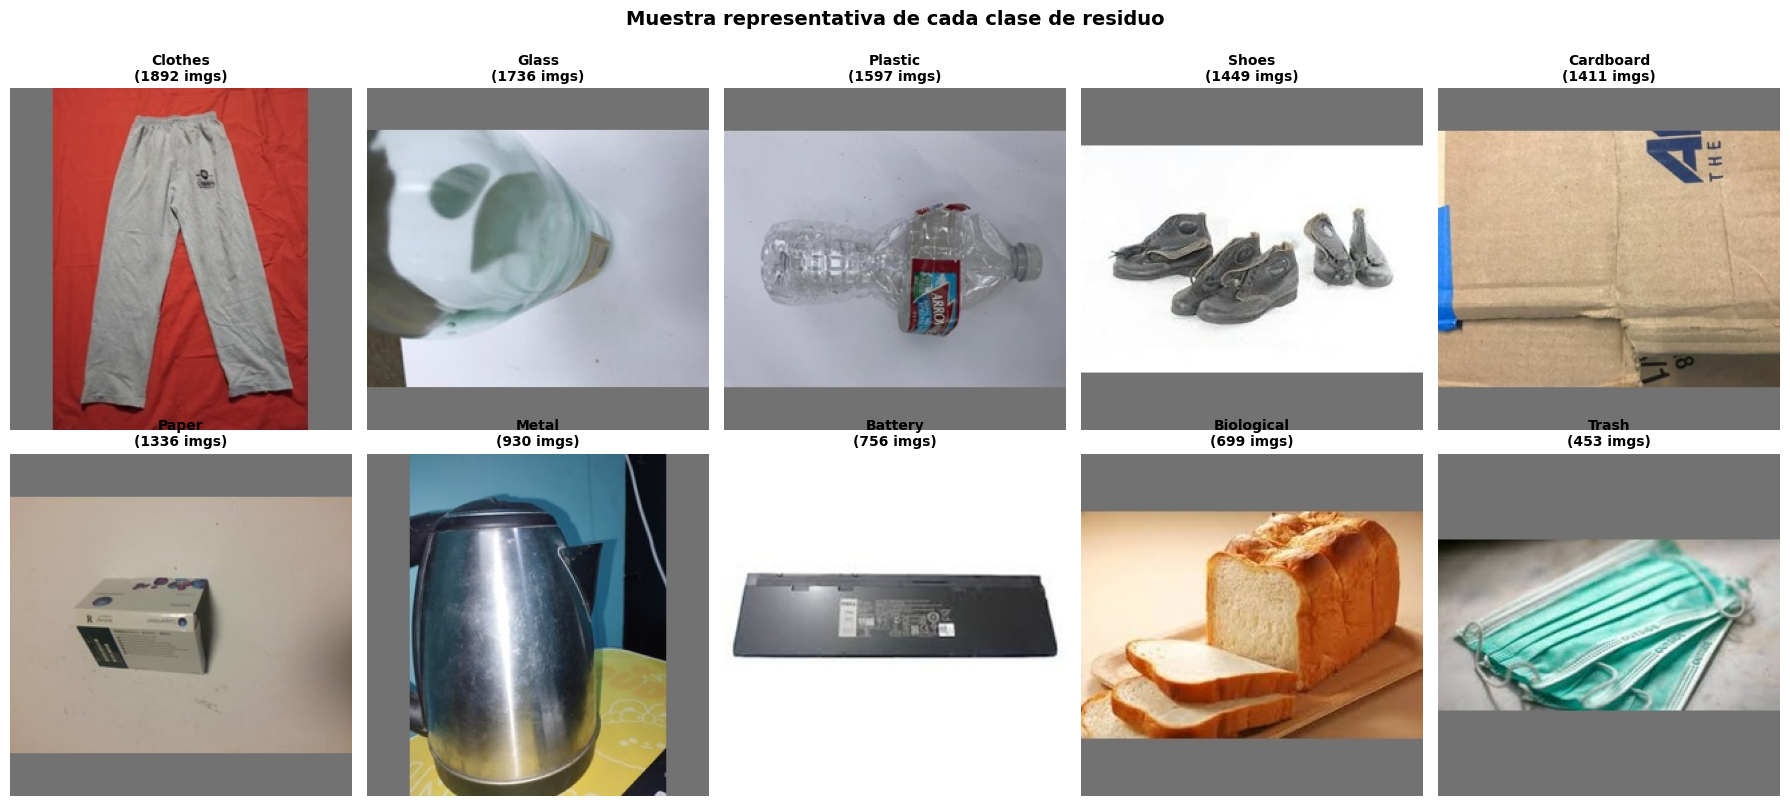

In [ ]:
from PIL import Image
import random

# Fijar semilla para reproducibilidad de las muestras mostradas
random.seed(42)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(df_stats['Clase']):
    cls_path = os.path.join(data_dir, cls)
    # Obtener lista de archivos de imagen válidos
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    # Seleccionar una imagen aleatoria de la clase
    sample_img = random.choice(imgs)
    img = Image.open(os.path.join(cls_path, sample_img)).convert('RGB')

    axes[i].imshow(img)
    axes[i].set_title(f'{cls.capitalize()}\n({df_stats[df_stats["Clase"]==cls]["Cantidad"].values[0]} imgs)',
                      fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Muestra representativa de cada clase de residuo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('muestras_clases.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Preprocesamiento y Data Augmentation

El preprocesamiento adapta las imágenes al formato esperado por CoAtNet:
- **Resize a 224×224:** Tamaño estándar del modelo preentrenado.
- **Data Augmentation (solo en train):** Aumenta artificialmente la diversidad del dataset para mejorar la generalización y reducir el sobreajuste.
- **Normalización ImageNet:** Los pesos preentrenados fueron entrenados con imágenes normalizadas con media=[0.485, 0.456, 0.406] y std=[0.229, 0.224, 0.225].

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

# Hiperparámetros globales
IMG_SIZE    = 224          # Tamaño de entrada estándar para CoAtNet
BATCH_SIZE  = 64           # Número de imágenes por batch (ajustar según memoria GPU)
NUM_WORKERS = 2            # Hilos paralelos para cargar datos
EPOCHS      = 10           # Número de épocas de entrenamiento completo
LR          = 1e-4         # Tasa de aprendizaje inicial (AdamW)
WEIGHT_DECAY = 1e-2        # Regularización L2 del optimizador
SEED        = 42           # Semilla para reproducibilidad

# Fijar semilla global para reproducibilidad en PyTorch y NumPy
torch.manual_seed(SEED)
np.random.seed(SEED)

# Detectar dispositivo disponible (GPU si está disponible, sino CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"  Dispositivo de cómputo: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Transformaciones para el conjunto de ENTRENAMIENTO
train_transforms = transforms.Compose([
    # 1. Redimensionar y recortar aleatoriamente para simular diferentes distancias
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    # 2. Voltear horizontalmente con probabilidad 50% (la basura no tiene orientación fija)
    transforms.RandomHorizontalFlip(p=0.5),
    # 3. Rotación aleatoria ±15° (diferentes ángulos de captura)
    transforms.RandomRotation(degrees=15),
    # 4. Ajustes de color para simular diferentes condiciones de iluminación
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    # 5. Convertir imagen PIL a tensor PyTorch (valores de 0.0 a 1.0)
    transforms.ToTensor(),
    # 6. Normalizar con estadísticas de ImageNet (requerido para pesos preentrenados)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para VALIDACIÓN (sin augmentation)
val_transforms = transforms.Compose([
    # 1. Redimensionar para que el lado menor sea IMG_SIZE+32 (para el crop central)
    transforms.Resize(IMG_SIZE + 32),
    # 2. Recorte central estándar al tamaño esperado por el modelo
    transforms.CenterCrop(IMG_SIZE),
    # 3. Convertir a tensor
    transforms.ToTensor(),
    # 4. Normalizar igual que entrenamiento
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

  Dispositivo de cómputo: cuda
   GPU detectada: Tesla T4
   Memoria GPU disponible: 15.6 GB


In [ ]:
# Cargar el dataset y dividir en train/validación
# División: 80% entrenamiento / 20% validación (split aleatorio estratificado)
# Se Aplico transforms diferentes a cada split usando Subset + overriding.

from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

# Cargar dataset completo con transforms de validación primero (para obtener índices)
full_dataset = datasets.ImageFolder(root=data_dir, transform=val_transforms)
NUM_CLASSES = len(full_dataset.classes)
class_names = full_dataset.classes  # Lista de nombres de clases

# Obtener todas las etiquetas para hacer split estratificado
all_labels = [label for _, label in full_dataset.samples]

# Split estratificado: mantiene la misma proporción de clases en train y val
train_indices, val_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels  # Garantiza representación proporcional de todas las clases
)

# Crear subsets: train con augmentation, val sin augmentation
# Creamos datasets separados con sus respectivas transforms
train_dataset_full = datasets.ImageFolder(root=data_dir, transform=train_transforms)
val_dataset_full   = datasets.ImageFolder(root=data_dir, transform=val_transforms)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset   = Subset(val_dataset_full,   val_indices)

# Crear DataLoaders (iteradores que sirven batches al modelo)
# pin_memory=True: precargar datos en memoria GPU para mayor velocidad
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,              # Mezclar orden en cada época (evita patrones de orden)
    num_workers=NUM_WORKERS,   # Carga paralela de datos
    pin_memory=True            # Acelera transferencia CPU→GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,             # No mezclar en validación (consistencia)
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f" Dataset cargado y dividido correctamente:")
print(f"   Total de imágenes  : {len(full_dataset)}")
print(f"   Train              : {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.0f}%)")
print(f"   Validación         : {len(val_dataset)} ({len(val_dataset)/len(full_dataset)*100:.0f}%)")
print(f"   Clases             : {class_names}")
print(f"   Número de clases   : {NUM_CLASSES}")
print(f"   Batches por época  : {len(train_loader)} (train) / {len(val_loader)} (val)")

 Dataset cargado y dividido correctamente:
   Total de imágenes  : 12259
   Train              : 9807 (80%)
   Validación         : 2452 (20%)
   Clases             : ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
   Número de clases   : 10
   Batches por época  : 154 (train) / 39 (val)


---
## Carga del Modelo CoAtNet Preentrenado

Usamos **Transfer Learning**: cargamos pesos preentrenados en ImageNet-1k y reemplazamos la cabeza de clasificación para adaptarla a nuestras 10 clases de residuos. Esto aprovecha el conocimiento visual ya aprendido (bordes, texturas, formas) y requiere muchos menos datos y tiempo de entrenamiento.

In [ ]:
!pip install timm -q

In [ ]:
# Inicializar CoAtNet-0 con pesos preentrenados

# timm.create_model() hace 3 cosas automáticamente:
#   1. Construye la arquitectura CoAtNet-0
#   2. Descarga y carga pesos preentrenados en ImageNet
#   3. Reemplaza la capa de clasificación final por una nueva Linear(768, NUM_CLASSES)
#      (La nueva cabeza se inicializa aleatoriamente y se entrena desde cero)

# ¿Por qué coatnet_0_rw_224?
#   - coatnet_0: la variante más pequeña (~25M parámetros) — buena para T4
#   - rw: 'Ross Wightman' variant — implementación optimizada en timm
#   - 224: tamaño de entrada en el que fue preentrenado

model = timm.create_model(
    'coatnet_0_rw_224',   # Nombre del modelo en el registro de timm
    pretrained=True,       # Cargar pesos preentrenados en ImageNet
    num_classes=NUM_CLASSES  # Adaptar la cabeza final a nuestras 10 clases
)

# Mover el modelo a GPU (si está disponible) para entrenamiento acelerado
model = model.to(DEVICE)

# Estadísticas del modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f" Modelo CoAtNet-0 cargado exitosamente")
print(f"   Arquitectura    : {model.default_cfg['architecture']}")
print(f"   Dispositivo     : {DEVICE}")
print(f"   Total parámetros: {total_params:,}")
print(f"   Paráms entrenables: {trainable_params:,}")
print(f"   Clases de salida : {NUM_CLASSES}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

 Modelo CoAtNet-0 cargado exitosamente
   Arquitectura    : coatnet_0_rw_224
   Dispositivo     : cuda
   Total parámetros: 26,674,252
   Paráms entrenables: 26,674,252
   Clases de salida : 10


In [ ]:
# Configurar función de pérdida, optimizador y scheduler

# FUNCIÓN DE PÉRDIDA:
#   CrossEntropyLoss: estándar para clasificación multiclase.
#   label_smoothing=0.1: en lugar de targets 0/1 duros, usa 0.05/0.95.
#   Esto reduce el sobreajuste al evitar que el modelo sea demasiado 'confiado'.

# OPTIMIZADOR:
#   AdamW: variante de Adam con weight decay desacoplado.
#   - Adam adapta la tasa de aprendizaje por parámetro.
#   - weight_decay=1e-2 aplica regularización L2 real (sin afectar momentums).
#   Es el optimizador estándar para Transformers y modelos híbridos.

# SCHEDULER (ajuste de LR durante entrenamiento):
#   CosineAnnealingLR: reduce LR siguiendo una curva cosenoidal.
#   - Empieza en LR máximo, baja suavemente hasta LR mínimo.
#   - Permite 'calentar' primero (alta LR explora) y luego 'enfriar' (baja LR converge).
#   - T_max=EPOCHS: un ciclo completo a lo largo de todos los epochs.


# Función de pérdida con suavizado de etiquetas
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizador AdamW
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Scheduler de tasa de aprendizaje cosenoidal
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,   # Número de iteraciones para completar un ciclo
    eta_min=1e-6    # LR mínimo al final del ciclo
)

print(" Configuración de entrenamiento:")
print(f"   Pérdida    : CrossEntropyLoss (label_smoothing=0.1)")
print(f"   Optimizador: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"   Scheduler  : CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-6)")
print(f"   Épocas     : {EPOCHS}")

 Configuración de entrenamiento:
   Pérdida    : CrossEntropyLoss (label_smoothing=0.1)
   Optimizador: AdamW (lr=0.0001, weight_decay=0.01)
   Scheduler  : CosineAnnealingLR (T_max=10, eta_min=1e-6)
   Épocas     : 10


---
## Entrenamiento del Modelo

Entrenamos el modelo durante múltiples épocas, guardando el mejor modelo (según validación) para evitar sobreajuste. En cada época:
1. **Fase de entrenamiento:** El modelo actualiza sus pesos con backpropagation.
2. **Fase de validación:** Evaluamos sin actualizar pesos para medir generalización.
3. **Checkpoint:** Guardamos el modelo si mejora la accuracy de validación.

In [ ]:
# Definir funciones de entrenamiento y validación por época

from sklearn.metrics import balanced_accuracy_score
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Entrena el modelo durante una época completa.
    Retorna: pérdida promedio, accuracy (%) y balanced accuracy (%) de la época.
    """
    model.train()
    running_loss = 0.0
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss     = running_loss / len(loader.dataset)
    epoch_acc      = 100.0 * np.mean(np.array(all_preds) == np.array(all_labels))
    epoch_bal_acc  = 100.0 * balanced_accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_bal_acc


def validate(model, loader, criterion, device):
    """
    Evalúa el modelo en el conjunto de validación (sin actualizar pesos).
    Retorna: pérdida promedio, accuracy (%) y balanced accuracy (%) de validación.
    """
    model.eval()
    running_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss    = running_loss / len(loader.dataset)
    epoch_acc     = 100.0 * np.mean(np.array(all_preds) == np.array(all_labels))
    epoch_bal_acc = 100.0 * balanced_accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_bal_acc

In [ ]:
# Loop de entrenamiento principal con guardado del mejor modelo

# Estrategia 'Best Model Checkpoint':
#   - Evaluamos en validación después de cada época.
#   - Si la val_acc mejora, guardamos el modelo como 'mejor modelo'.
#   - Al final, cargamos el mejor modelo (no el del último epoch).
#   Esto protege contra el sobreajuste al final del entrenamiento.

import time

history = {
    'train_loss': [], 'train_acc': [], 'train_bal_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_bal_acc':   [],
    'lr':         []
}

best_val_bal_acc = 0.0
best_epoch       = 0

print("=" * 90)
print(f"   INICIANDO ENTRENAMIENTO — CoAtNet-0 | {EPOCHS} épocas | GPU: {DEVICE}")
print("=" * 90)
print(f"{'Época':>5} | {'LR':>8} | {'Train Loss':>10} | {'Train Acc':>9} | {'Train BAcc':>10} | "
      f"{'Val Loss':>8} | {'Val Acc':>8} | {'Val BAcc':>9} | {'Tiempo':>7}")
print("-" * 90)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Fase 1: Entrenamiento — ahora retorna 3 valores
    train_loss, train_acc, train_bal_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    # Fase 2: Validación — ahora retorna 3 valores
    val_loss, val_acc, val_bal_acc = validate(
        model, val_loader, criterion, DEVICE
    )

    # Fase 3: Scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    # Registrar historial
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_bal_acc'].append(train_bal_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_bal_acc'].append(val_bal_acc)
    history['lr'].append(current_lr)

    # Checkpoint: criterio = val balanced accuracy
    if val_bal_acc > best_val_bal_acc:
        best_val_bal_acc = val_bal_acc
        best_epoch       = epoch
        torch.save(model.state_dict(), 'best_coatnet_model.pth')
        checkpoint_marker = "  MEJOR"
    else:
        checkpoint_marker = ""

    epoch_time = time.time() - epoch_start
    print(f"{epoch:>5} | {current_lr:.2e} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{train_bal_acc:>9.2f}% | {val_loss:>8.4f} | {val_acc:>7.2f}% | "
          f"{val_bal_acc:>8.2f}%{checkpoint_marker} | {epoch_time:>5.1f}s")

total_time = time.time() - total_start
print("-" * 90)
print(f"\n Entrenamiento completado en {total_time/60:.1f} minutos")
print(f"★ Mejor modelo : Época {best_epoch}")
print(f"  Val Acc      = {history['val_acc'][best_epoch-1]:.2f}%")
print(f"  Val Bal Acc  = {best_val_bal_acc:.2f}%")
print(f"  Guardado en  : best_coatnet_model.pth")

   INICIANDO ENTRENAMIENTO — CoAtNet-0 | 10 épocas | GPU: cuda
Época |       LR | Train Loss | Train Acc | Train BAcc | Val Loss |  Val Acc |  Val BAcc |  Tiempo
------------------------------------------------------------------------------------------
    1 | 1.00e-04 |     0.8407 |    86.71% |     84.81% |   0.6632 |   93.43% |    92.56%  MEJOR | 180.7s
    2 | 9.76e-05 |     0.6302 |    94.96% |     94.48% |   0.6356 |   94.41% |    93.45%  MEJOR | 175.5s
    3 | 9.05e-05 |     0.5779 |    97.27% |     96.94% |   0.6387 |   94.45% |    93.94%  MEJOR | 175.4s
    4 | 7.96e-05 |     0.5481 |    98.31% |     98.24% |   0.6134 |   95.39% |    94.74%  MEJOR | 176.2s
    5 | 6.58e-05 |     0.5295 |    99.06% |     99.04% |   0.6276 |   94.98% |    94.57% | 175.4s
    6 | 5.05e-05 |     0.5170 |    99.59% |     99.55% |   0.6096 |   96.04% |    95.58%  MEJOR | 175.7s
    7 | 3.52e-05 |     0.5110 |    99.80% |     99.76% |   0.5952 |   96.25% |    95.54% | 175.2s
    8 | 2.14e-05 |     0.5

---
## Curvas de Entrenamiento

Visualizamos cómo evolucionaron la pérdida y el accuracy a lo largo de las épocas. Esto nos permite detectar:
- **Sobreajuste (overfitting):** Train acc sube pero val acc se estanca o baja.
- **Subajuste (underfitting):** Ambas métricas son bajas.
- **Convergencia saludable:** Train y val acc suben juntas y se estabilizan.

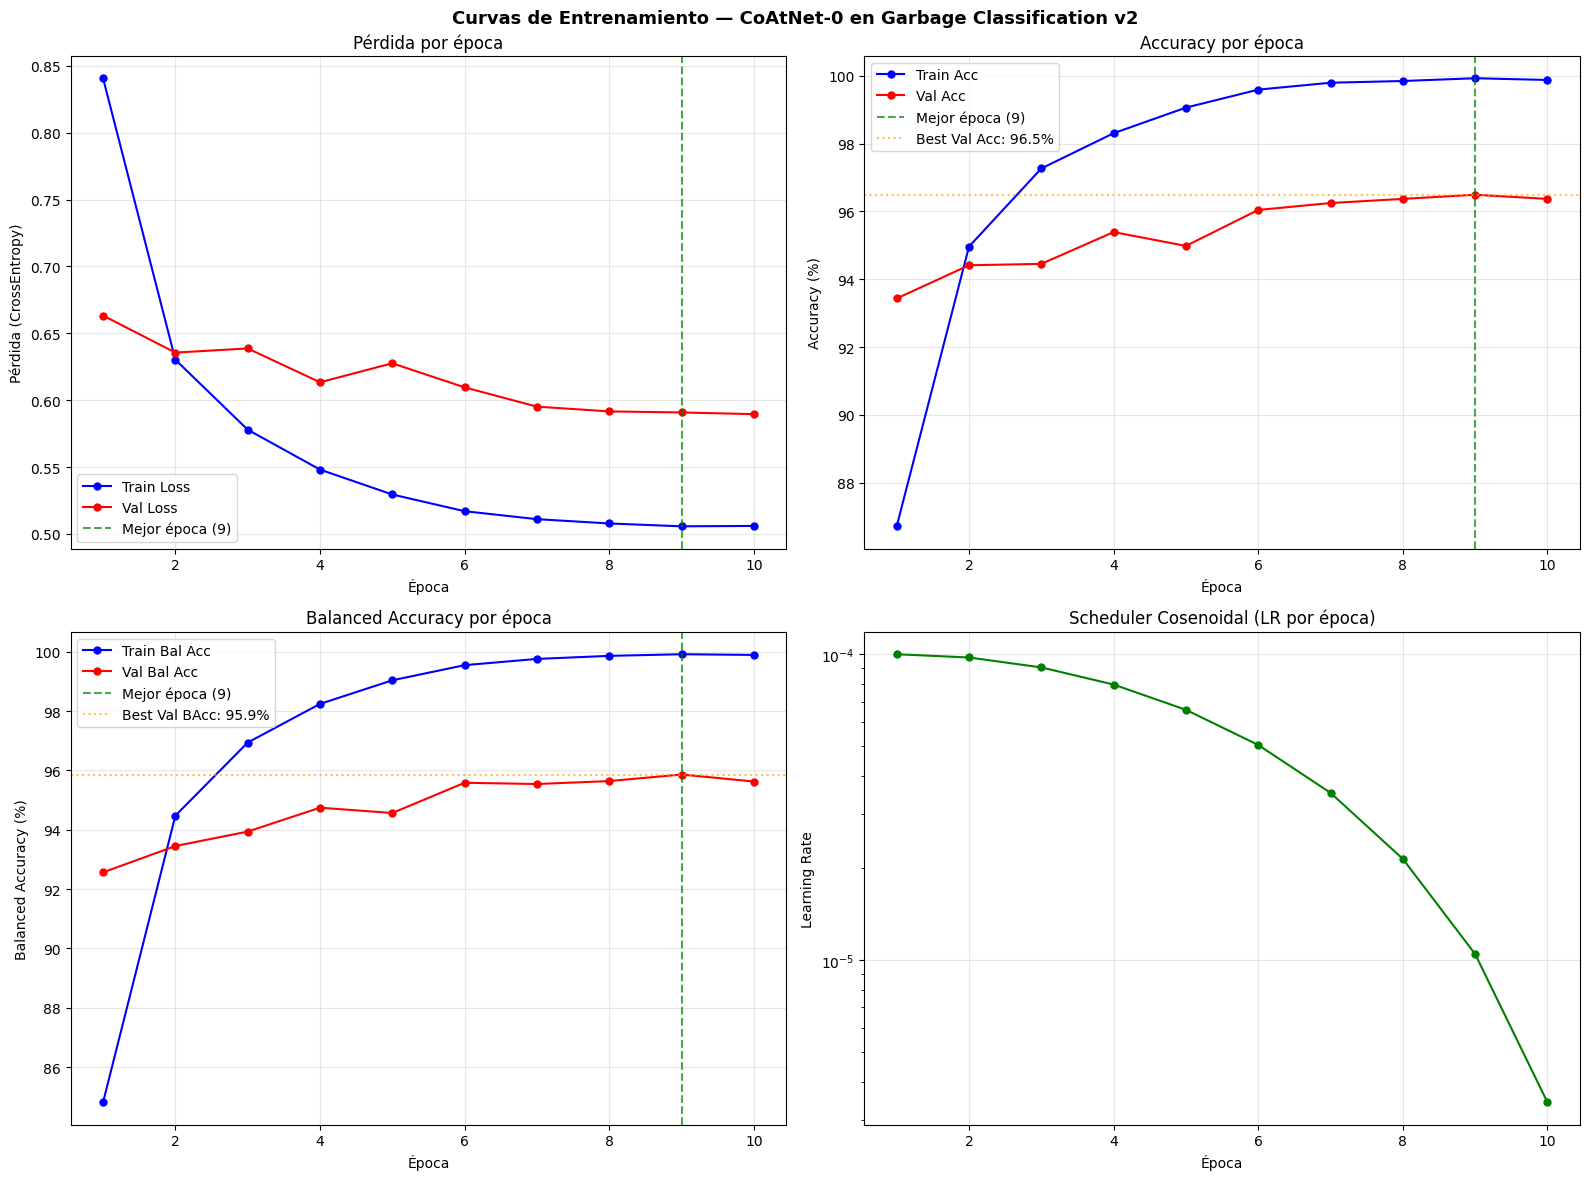


 Resumen del entrenamiento:
   Mejor época            : 9
   Val Acc  (mejor época) : 96.49%
   Val BAcc (mejor época) : 95.86%
   Train Acc final        : 99.88%
   Train BAcc final       : 99.90%
   Val Acc final          : 96.37%
   Val BAcc final         : 95.63%
   Brecha Acc  train-val  : 3.51%  (generalización saludable)
   Brecha BAcc train-val  : 4.27% (generalización saludable)


In [ ]:
# Graficar curvas de entrenamiento

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Curvas de Entrenamiento — CoAtNet-0 en Garbage Classification v2',
             fontsize=13, fontweight='bold')

# Gráfica 1: Curvas de pérdida
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=5)
axes[0, 0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=5)
axes[0, 0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_epoch})')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Pérdida (CrossEntropy)')
axes[0, 0].set_title('Pérdida por época')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfica 2: Curvas de accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=5)
axes[0, 1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   markersize=5)
axes[0, 1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_epoch})')
axes[0, 1].axhline(history['val_acc'][best_epoch - 1], color='orange', linestyle=':',
                   alpha=0.7, label=f"Best Val Acc: {history['val_acc'][best_epoch-1]:.1f}%")
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy por época')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfica 3: Curvas de balanced accuracy
axes[1, 0].plot(epochs_range, history['train_bal_acc'], 'b-o', label='Train Bal Acc', markersize=5)
axes[1, 0].plot(epochs_range, history['val_bal_acc'],   'r-o', label='Val Bal Acc',   markersize=5)
axes[1, 0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_epoch})')
axes[1, 0].axhline(best_val_bal_acc, color='orange', linestyle=':',
                   alpha=0.7, label=f'Best Val BAcc: {best_val_bal_acc:.1f}%')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Balanced Accuracy (%)')
axes[1, 0].set_title('Balanced Accuracy por época')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfica 4: Evolución de la tasa de aprendizaje
axes[1, 1].plot(epochs_range, history['lr'], 'g-o', markersize=5)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Scheduler Cosenoidal (LR por época)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico
best_val_acc_at_checkpoint = history['val_acc'][best_epoch - 1]

print(f"\n Resumen del entrenamiento:")
print(f"   Mejor época            : {best_epoch}")
print(f"   Val Acc  (mejor época) : {best_val_acc_at_checkpoint:.2f}%")
print(f"   Val BAcc (mejor época) : {best_val_bal_acc:.2f}%")
print(f"   Train Acc final        : {history['train_acc'][-1]:.2f}%")
print(f"   Train BAcc final       : {history['train_bal_acc'][-1]:.2f}%")
print(f"   Val Acc final          : {history['val_acc'][-1]:.2f}%")
print(f"   Val BAcc final         : {history['val_bal_acc'][-1]:.2f}%")

gap_acc  = history['train_acc'][-1]     - history['val_acc'][-1]
gap_bacc = history['train_bal_acc'][-1] - history['val_bal_acc'][-1]
print(f"   Brecha Acc  train-val  : {gap_acc:.2f}%  ({'sobreajuste leve' if gap_acc  > 5 else 'generalización saludable'})")
print(f"   Brecha BAcc train-val  : {gap_bacc:.2f}% ({'sobreajuste leve' if gap_bacc > 5 else 'generalización saludable'})")

---
## Evaluación Detallada del Mejor Modelo

Cargamos el mejor modelo guardado y realizamos una evaluación exhaustiva:
- **Matriz de confusión:** Muestra qué clases se confunden entre sí.
- **Reporte de clasificación:** Precision, Recall y F1-score por clase.
- **Accuracy global** en el conjunto de validación.

In [ ]:
# Cargar el mejor modelo guardado durante el entrenamiento

model.load_state_dict(torch.load('best_coatnet_model.pth', map_location=DEVICE))
model.eval()

print(f" Mejor modelo cargado (Época {best_epoch})")
print(f"  Val Acc      : {history['val_acc'][best_epoch-1]:.2f}%")
print(f"  Val Bal Acc  : {best_val_bal_acc:.2f}%")

 Mejor modelo cargado (Época 9)
  Val Acc      : 96.49%
  Val Bal Acc  : 95.86%


In [ ]:
# Obtener todas las predicciones sobre el conjunto de validación

# Para métricas más ricas (precision, recall, F1, matriz de confusión) necesitamos
# las predicciones y etiquetas reales de TODOS los ejemplos de validación.

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

all_preds  = []   # Lista para acumular predicciones
all_labels = []   # Lista para acumular etiquetas reales
all_probs  = []   # Lista para acumular probabilidades (para análisis adicional)

print(" Generando predicciones sobre el conjunto de validación...")

model.eval()
with torch.no_grad():   # Sin gradientes para mayor eficiencia
    for images, labels in val_loader:
        images = images.to(DEVICE)

        # Forward pass: obtener logits
        outputs = model(images)                           # (batch, 10)

        # Convertir logits a probabilidades con softmax
        probs = torch.softmax(outputs, dim=1)             # (batch, 10)

        # Obtener clase predicha (argmax de probabilidades)
        _, predicted = outputs.max(1)                     # (batch,)

        # Acumular en listas CPU (numpy)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

# Convertir a arrays numpy para usar con sklearn
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Calcular accuracy global
final_acc = accuracy_score(all_labels, all_preds) * 100
final_bal_acc  = balanced_accuracy_score(all_labels, all_preds) * 100

print(f"\n Evaluación completada sobre {len(all_labels)} imágenes de validación")
print(f" Accuracy global: {final_acc:.2f}%")
print(f"  Balanced Accuracy : {final_bal_acc:.2f}%")
print("\n" + "=" * 65)
print(" REPORTE DE CLASIFICACIÓN POR CLASE:")
print("=" * 65)
print(classification_report(
    all_labels, all_preds,
    target_names=[c.capitalize() for c in class_names],
    digits=3   # 3 decimales para mayor precisión
))

 Generando predicciones sobre el conjunto de validación...

 Evaluación completada sobre 2452 imágenes de validación
 Accuracy global: 96.49%
  Balanced Accuracy : 95.86%

 REPORTE DE CLASIFICACIÓN POR CLASE:
              precision    recall  f1-score   support

     Battery      0.987     1.000     0.993       151
  Biological      1.000     0.979     0.989       140
   Cardboard      0.964     0.957     0.961       282
     Clothes      0.997     0.995     0.996       379
       Glass      0.960     0.971     0.966       347
       Metal      0.923     0.973     0.948       186
       Paper      0.930     0.944     0.937       267
     Plastic      0.952     0.925     0.938       319
       Shoes      0.990     0.997     0.993       290
       Trash      0.917     0.846     0.880        91

    accuracy                          0.965      2452
   macro avg      0.962     0.959     0.960      2452
weighted avg      0.965     0.965     0.965      2452



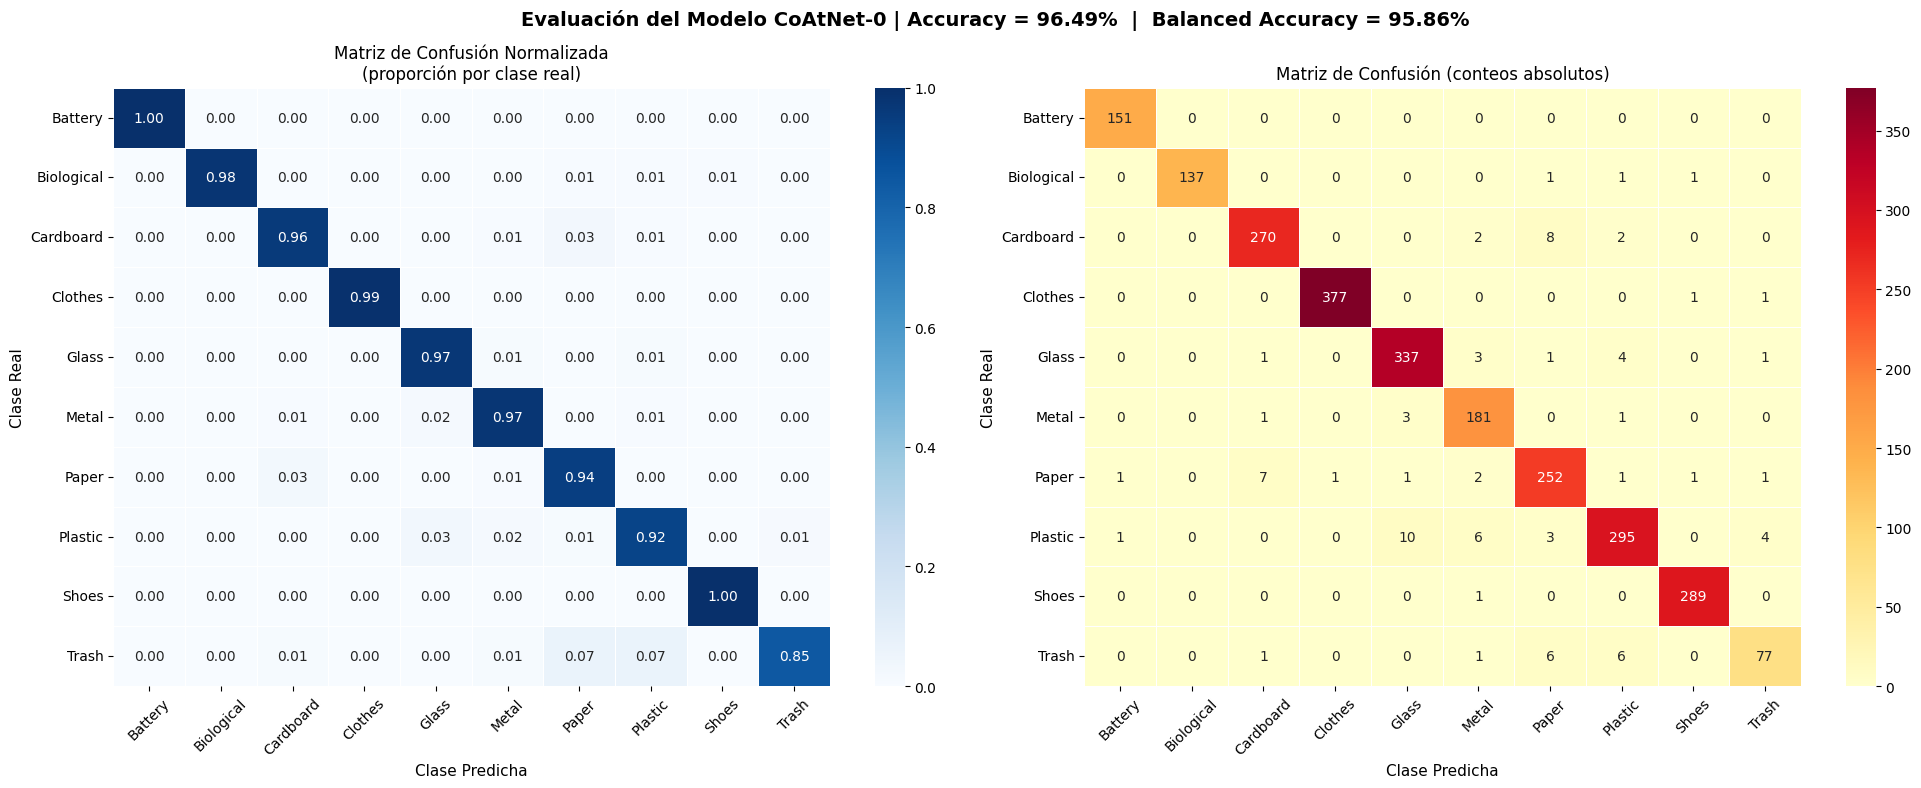


 Principales confusiones del modelo:
   Plastic      → Glass       : 10 errores
   Cardboard    → Paper       : 8 errores
   Paper        → Cardboard   : 7 errores
   Trash        → Paper       : 6 errores
   Plastic      → Metal       : 6 errores


In [ ]:
# Visualizar la Matriz de Confusión

# La matriz de confusión muestra:
#   - Diagonal (verde): predicciones correctas por clase
#   - Fuera de diagonal: errores (fila = clase real, columna = clase predicha)

# Interpretación: si cm[i][j] es alto, el modelo confunde la clase i con j.
# Esto ayuda a identificar pares de clases similares (ej: vidrio vs plástico).

# Calcular la matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Normalizar la matriz (cada fila suma 1) para ver proporciones por clase
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
class_labels = [c.capitalize() for c in class_names]

# Matriz de confusión normalizada
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Matriz de Confusión Normalizada\n(proporción por clase real)', fontsize=12)
axes[0].set_ylabel('Clase Real', fontsize=11)
axes[0].set_xlabel('Clase Predicha', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Matriz de confusión con conteos absolutos
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Matriz de Confusión (conteos absolutos)', fontsize=12)
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_xlabel('Clase Predicha', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(
    f'Evaluación del Modelo CoAtNet-0 | '
    f'Accuracy = {final_acc:.2f}%  |  Balanced Accuracy = {final_bal_acc:.2f}%',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar las principales confusiones
print("\n Principales confusiones del modelo:")
# Excluir la diagonal y encontrar los errores más frecuentes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top_errors = np.unravel_index(np.argsort(cm_no_diag.ravel())[-5:], cm_no_diag.shape)
for r, c in zip(top_errors[0][::-1], top_errors[1][::-1]):
    if cm_no_diag[r, c] > 0:
        print(f"   {class_names[r].capitalize():12} → {class_names[c].capitalize():12}: {cm_no_diag[r,c]} errores")

---
## Visualización de Predicciones

Mostramos predicciones individuales del modelo sobre imágenes de validación, con la probabilidad de confianza, para entender visualmente cómo toma decisiones.

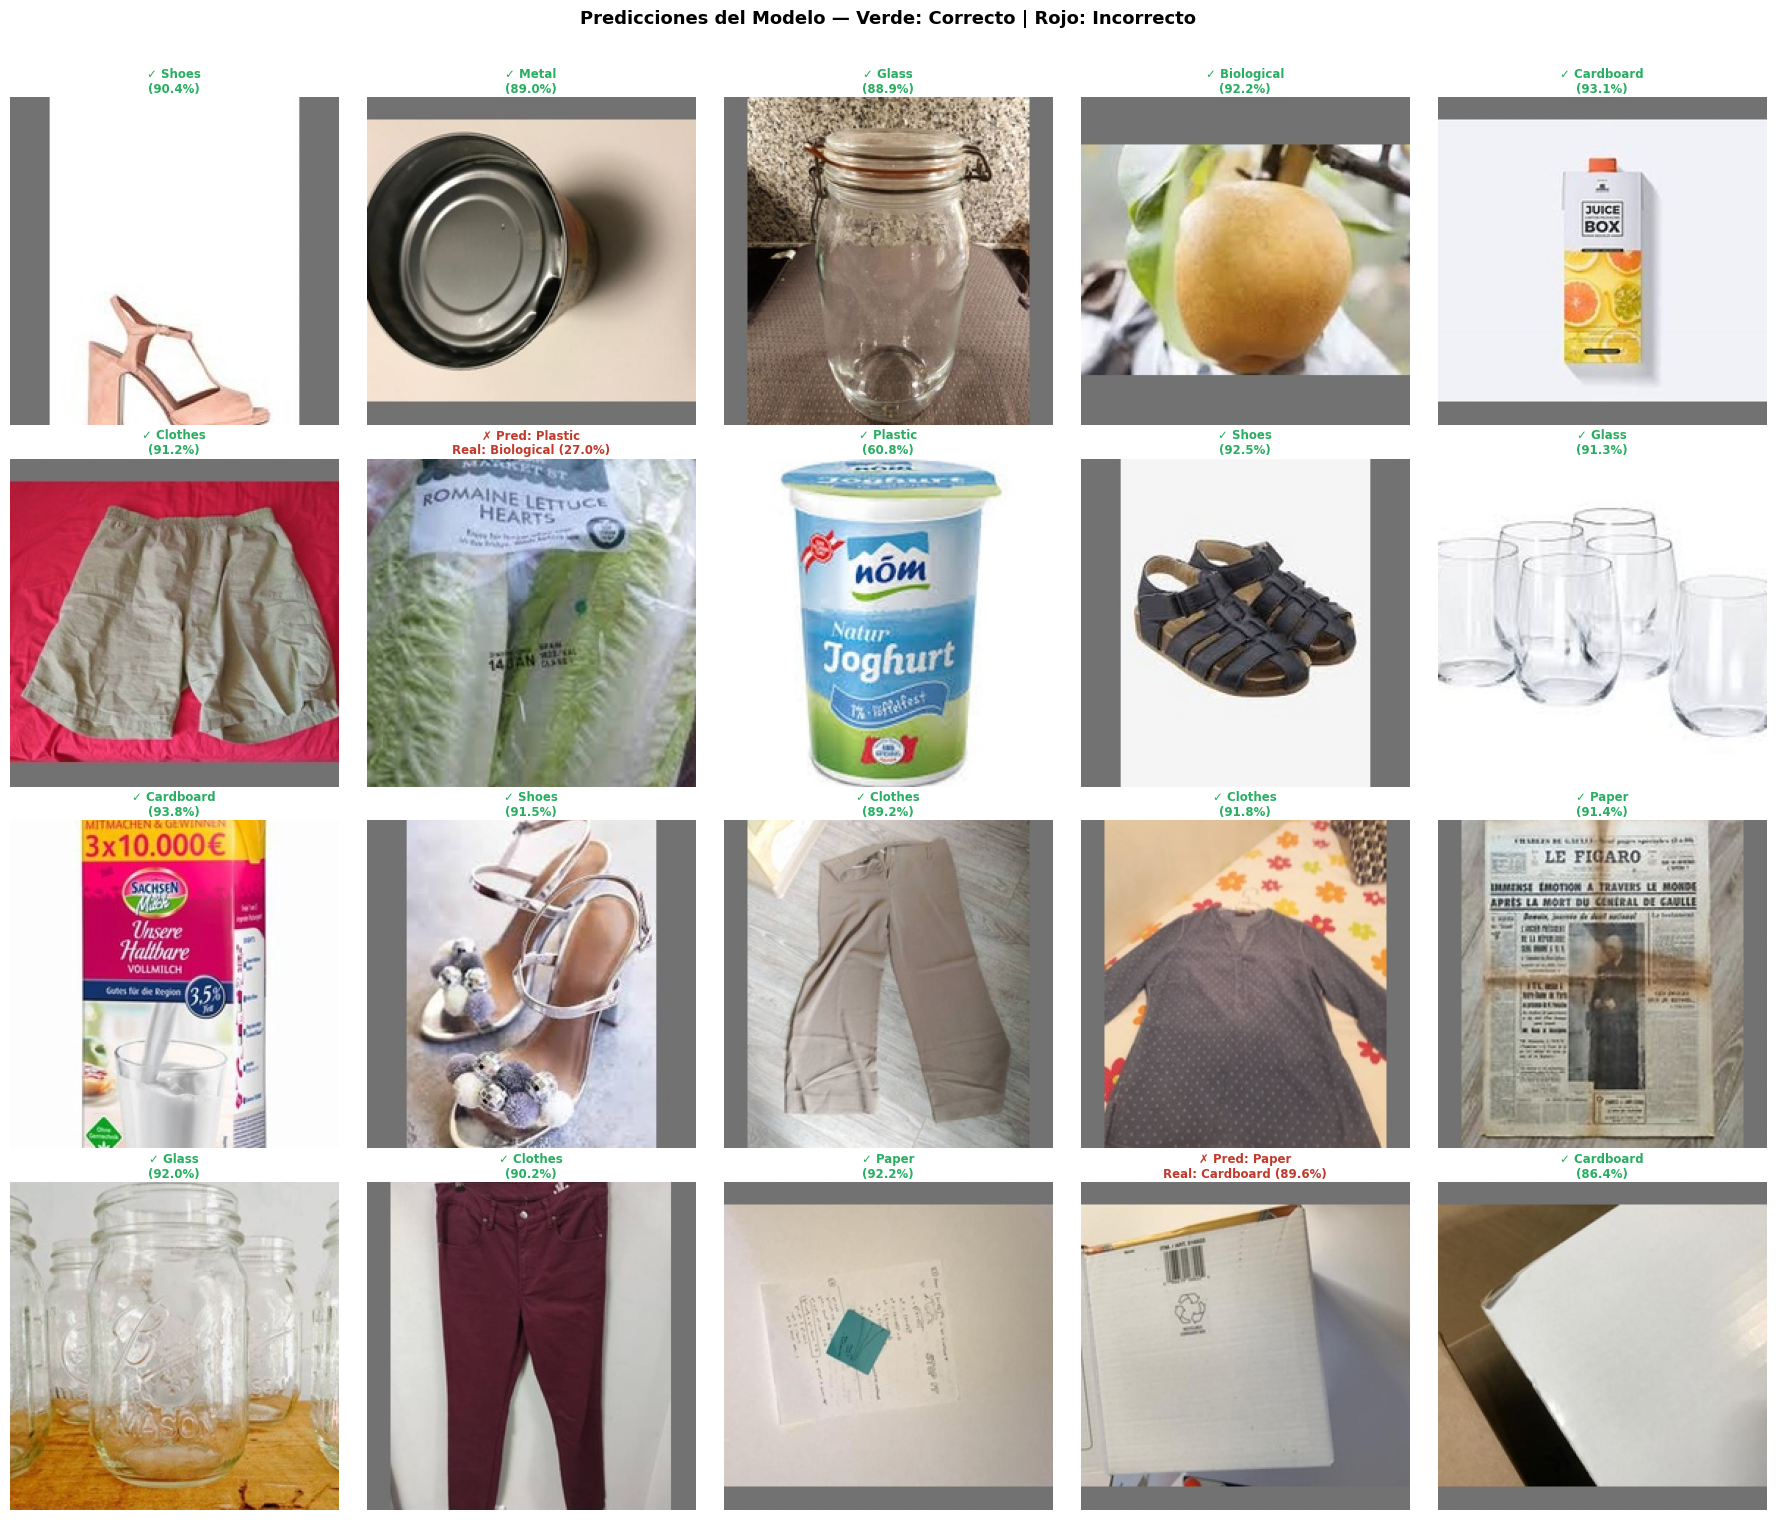


 Precisión en este batch (64 imágenes):
   Accuracy          : 59/64 (92%)
   Balanced Accuracy : 93.9%
   (visualizadas: primeras 20 de 64)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [ ]:
# Visualizar predicciones correctas e incorrectas del modelo

# Mostramos una cuadrícula de imágenes con:
#   - Verde: predicción correcta (clase predicha == clase real)
#   - Rojo: predicción incorrecta (con la clase real indicada)
#   - Porcentaje de confianza del modelo

from torchvision.transforms.functional import to_pil_image

# Función para desnormalizar la imagen (revertir la normalización ImageNet)
# para que pueda mostrarse visualmente correcta
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Revierte la normalización ImageNet para visualización."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Obtener un batch de validación para visualizar
val_iter = iter(val_loader)
images_batch, labels_batch = next(val_iter)

# Obtener predicciones del modelo
model.eval()
with torch.no_grad():
    outputs = model(images_batch.to(DEVICE))
    probs_batch = torch.softmax(outputs, dim=1)
    predicted_batch = outputs.argmax(dim=1).cpu()
    confidence_batch = probs_batch.max(dim=1).values.cpu()

# Visualizar las primeras 20 imágenes del batch
n_show = min(20, len(images_batch))
fig, axes = plt.subplots(4, 5, figsize=(18, 15))
axes = axes.flatten()

for idx in range(n_show):
    # Desnormalizar imagen para visualización
    img = denormalize(images_batch[idx])
    img_np = img.permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)

    pred_class = predicted_batch[idx].item()
    true_class = labels_batch[idx].item()
    conf       = confidence_batch[idx].item()
    is_correct = (pred_class == true_class)

    # Color del borde: verde si correcto, rojo si incorrecto
    border_color = '#2ecc71' if is_correct else '#e74c3c'

    axes[idx].imshow(img_np)
    axes[idx].axis('off')

    # Añadir borde de color alrededor de la imagen
    for spine in axes[idx].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    axes[idx].set_frame_on(True)

    # Título con predicción y confianza
    if is_correct:
        title = f'✓ {class_names[pred_class].capitalize()}\n({conf:.1%})'
        title_color = '#27ae60'
    else:
        title = f'✗ Pred: {class_names[pred_class].capitalize()}\nReal: {class_names[true_class].capitalize()} ({conf:.1%})'
        title_color = '#c0392b'

    axes[idx].set_title(title, fontsize=8.5, color=title_color, fontweight='bold', pad=3)

plt.suptitle('Predicciones del Modelo — Verde: Correcto | Rojo: Incorrecto',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('predicciones_visuales.png', dpi=150, bbox_inches='tight')
plt.show()

batch_correct  = (predicted_batch == labels_batch).sum().item()
batch_total    = len(labels_batch)   # tamaño real del batch
batch_bal_acc  = balanced_accuracy_score(
    labels_batch.numpy(),
    predicted_batch.numpy()
) * 100

print(f"\n Precisión en este batch ({batch_total} imágenes):")
print(f"   Accuracy          : {batch_correct}/{batch_total} ({batch_correct/batch_total*100:.0f}%)")
print(f"   Balanced Accuracy : {batch_bal_acc:.1f}%")
print(f"   (visualizadas: primeras {n_show} de {batch_total})")

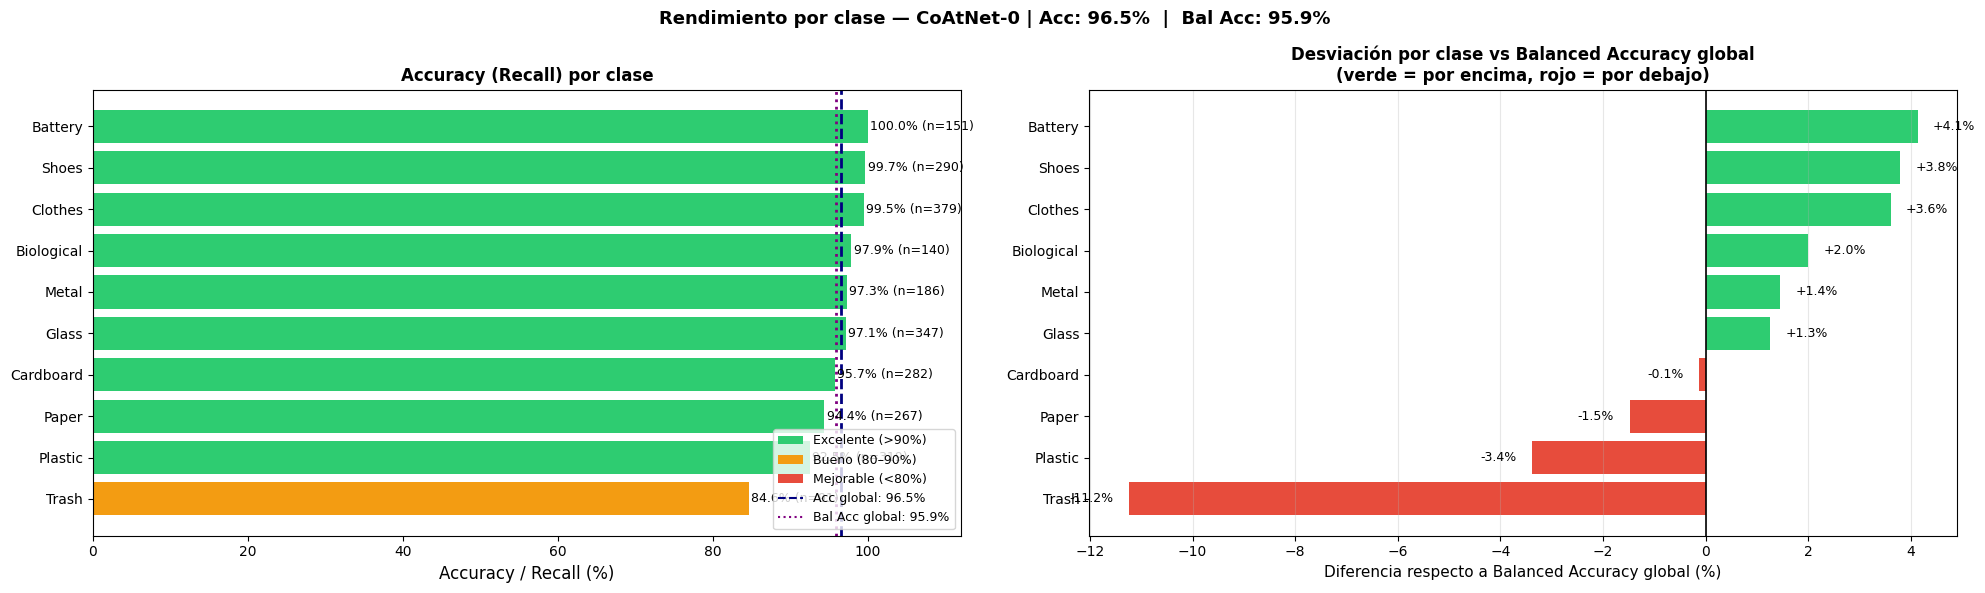


 Accuracy detallado por clase:
   🟢 Battery     : 100.0%  (+4.1% vs Bal Acc global)
   🟢 Shoes       : 99.7%  (+3.8% vs Bal Acc global)
   🟢 Clothes     : 99.5%  (+3.6% vs Bal Acc global)
   🟢 Biological  : 97.9%  (+2.0% vs Bal Acc global)
   🟢 Metal       : 97.3%  (+1.4% vs Bal Acc global)
   🟢 Glass       : 97.1%  (+1.3% vs Bal Acc global)
   🟢 Cardboard   : 95.7%  (-0.1% vs Bal Acc global)
   🟢 Paper       : 94.4%  (-1.5% vs Bal Acc global)
   🟢 Plastic     : 92.5%  (-3.4% vs Bal Acc global)
   🟡 Trash       : 84.6%  (-11.2% vs Bal Acc global)


In [ ]:
from matplotlib.patches import Patch

# Métricas por clase desde la matriz de confusión
per_class_acc    = cm.diagonal() / cm.sum(axis=1) * 100   # recall por clase = acc por clase
per_class_counts = cm.sum(axis=1)

df_per_class = pd.DataFrame({
    'Clase':        [c.capitalize() for c in class_names],
    'Accuracy (%)': per_class_acc,
    'Cantidad val': per_class_counts
}).sort_values('Accuracy (%)', ascending=True)

def bar_color(acc):
    return '#e74c3c' if acc < 80 else '#f39c12' if acc < 90 else '#2ecc71'

colors_bar = [bar_color(acc) for acc in df_per_class['Accuracy (%)']]

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Gráfica 1: Accuracy por clase con línea de accuracy global
bars = axes[0].barh(df_per_class['Clase'], df_per_class['Accuracy (%)'], color=colors_bar)
axes[0].axvline(final_acc, color='navy', linestyle='--', linewidth=2,
                label=f'Accuracy global: {final_acc:.1f}%')
axes[0].axvline(final_bal_acc, color='purple', linestyle=':', linewidth=2,
                label=f'Balanced Acc global: {final_bal_acc:.1f}%')

for bar, val, n in zip(bars, df_per_class['Accuracy (%)'], df_per_class['Cantidad val']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}% (n={n})', va='center', fontsize=9)

axes[0].set_xlim(0, 112)
axes[0].set_xlabel('Accuracy / Recall (%)', fontsize=12)
axes[0].set_title('Accuracy (Recall) por clase', fontsize=12, fontweight='bold')

legend_elements = [
    Patch(facecolor='#2ecc71', label='Excelente (>90%)'),
    Patch(facecolor='#f39c12', label='Bueno (80–90%)'),
    Patch(facecolor='#e74c3c', label='Mejorable (<80%)'),
    plt.Line2D([0], [0], color='navy',   linestyle='--', label=f'Acc global: {final_acc:.1f}%'),
    plt.Line2D([0], [0], color='purple', linestyle=':',  label=f'Bal Acc global: {final_bal_acc:.1f}%'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# Gráfica 2: Brecha entre Accuracy global y Recall por clase
gap = per_class_acc - final_bal_acc   # qué tan por encima/debajo de la media está cada clase
df_gap = pd.DataFrame({
    'Clase': [c.capitalize() for c in class_names],
    'Gap':   gap
}).sort_values('Gap', ascending=True)

colors_gap = ['#e74c3c' if g < 0 else '#2ecc71' for g in df_gap['Gap']]
axes[1].barh(df_gap['Clase'], df_gap['Gap'], color=colors_gap)
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_xlabel('Diferencia respecto a Balanced Accuracy global (%)', fontsize=11)
axes[1].set_title('Desviación por clase vs Balanced Accuracy global\n'
                  '(verde = por encima, rojo = por debajo)', fontsize=12, fontweight='bold')

for i, (val, clase) in enumerate(zip(df_gap['Gap'], df_gap['Clase'])):
    axes[1].text(val + (0.3 if val >= 0 else -0.3), i,
                 f'{val:+.1f}%', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

axes[1].grid(True, axis='x', alpha=0.3)

plt.suptitle('Rendimiento por clase — CoAtNet-0 | '
             f'Acc: {final_acc:.1f}%  |  Bal Acc: {final_bal_acc:.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen en consola
print("\n Accuracy detallado por clase:")
for _, row in df_per_class.sort_values('Accuracy (%)', ascending=False).iterrows():
    emoji = '🟢' if row['Accuracy (%)'] >= 90 else '🟡' if row['Accuracy (%)'] >= 80 else '🔴'
    gap_val = row['Accuracy (%)'] - final_bal_acc
    print(f"   {emoji} {row['Clase']:12}: {row['Accuracy (%)']:.1f}%  ({gap_val:+.1f}% vs Bal Acc global)")

🔄 Cargando modelo...
✅ Modelo cargado exitosamente

                         PREDICCIONES DE RESIDUOS

📸 bottle.jpg
   ──────────────────────────────────────────────────
   ✅ Predicción: PLASTIC
   📊 Confianza: 91.44%

   🏆 Top 3:
      1. plastic      ████████████████████████████████████ 91.44%
      2. cardboard     1.05%
      3. metal         1.05%

📸 camiseta.jpg
   ──────────────────────────────────────────────────
   ✅ Predicción: CLOTHES
   📊 Confianza: 89.55%

   🏆 Top 3:
      1. clothes      ███████████████████████████████████ 89.55%
      2. metal         1.40%
      3. plastic       1.29%

📸 carton.jpg
   ──────────────────────────────────────────────────
   ✅ Predicción: CARDBOARD
   📊 Confianza: 44.51%

   🏆 Top 3:
      1. cardboard    █████████████████ 44.51%
      2. paper        ████████████████ 42.26%
      3. glass         1.93%

📸 zapato.jpg
   ──────────────────────────────────────────────────
   ✅ Predicción: SHOES
   📊 Confianza: 90.54%

   🏆 Top 3:
      1. sh

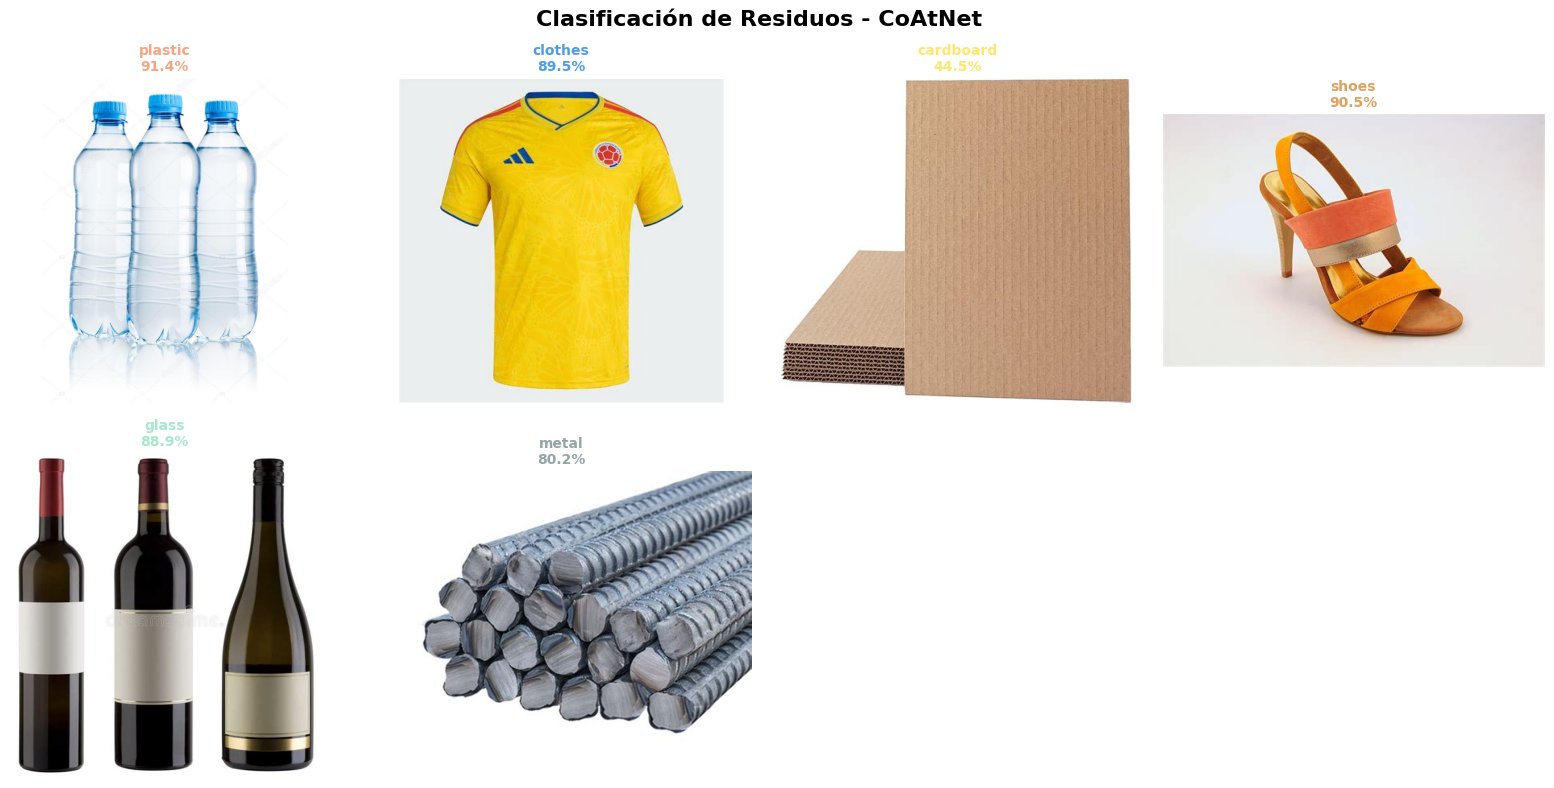

📊 Visualización guardada en: mis_predicciones.png

ANÁLISIS DE CONFIANZA (Umbral: 60%)

bottle.jpg: plastic (91.44%) ✅ ALTA CONFIANZA

camiseta.jpg: clothes (89.55%) ✅ ALTA CONFIANZA

carton.jpg: cardboard (44.51%) ⚠️  BAJA CONFIANZA

zapato.jpg: shoes (90.54%) ✅ ALTA CONFIANZA

vino.jpg: glass (88.88%) ✅ ALTA CONFIANZA

varilla.jpg: metal (80.24%) ✅ ALTA CONFIANZA

⚠️  IMÁGENES CON BAJA CONFIANZA (revisar manualmente):
   - carton.jpg: cardboard (44.51%)
     Posible alternativa: paper (42.26%)

📋 RESUMEN FINAL
   bottle.jpg      → plastic      (confianza: 91.44%)
   camiseta.jpg    → clothes      (confianza: 89.55%)
   carton.jpg      → cardboard    (confianza: 44.51%)
   zapato.jpg      → shoes        (confianza: 90.54%)
   vino.jpg        → glass        (confianza: 88.88%)
   varilla.jpg     → metal        (confianza: 80.24%)

♻️  RECOMENDACIONES DE RECICLAJE

• bottle.jpg
  → PLASTIC: 🥤 Depositar en contenedor amarillo (envases)

• camiseta.jpg
  → CLOTHES: 👕 Donar o depositar en 

In [13]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import timm
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Configuración
IMG_SIZE = 224
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Transformaciones de validación
val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Clases en orden alfabético
classes = [
    'battery',      # 0
    'biological',   # 1
    'cardboard',    # 2
    'clothes',      # 3
    'glass',        # 4
    'metal',        # 5
    'paper',        # 6
    'plastic',      # 7
    'shoes',        # 8
    'trash'         # 9
]

# Cargar modelo
print("🔄 Cargando modelo...")
model = timm.create_model('coatnet_0_rw_224', pretrained=False, num_classes=10)
checkpoint = torch.load('best_coatnet_model.pth', map_location=DEVICE)
model.load_state_dict(checkpoint)
model = model.to(DEVICE)
model.eval()
print("✅ Modelo cargado exitosamente\n")

def predict_single_image(image_path, return_details=False):
    """Predice una sola imagen"""
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transforms(image)
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_class = torch.argmax(outputs, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    if return_details:
        return {
            'image_path': image_path,
            'image_name': os.path.basename(image_path),
            'predicted_class': classes[predicted_class],
            'class_id': predicted_class,
            'confidence': confidence,
            'all_probabilities': probabilities[0].cpu().numpy()
        }
    else:
        return classes[predicted_class], confidence

def predict_multiple_images(image_paths):
    """Predice múltiples imágenes y muestra resultados"""
    results = []

    # Eliminar duplicados manteniendo orden
    unique_paths = []
    seen = set()
    for path in image_paths:
        if path not in seen:
            seen.add(path)
            unique_paths.append(path)

    print("="*80)
    print(" " * 25 + "PREDICCIONES DE RESIDUOS")
    print("="*80)

    for img_path in unique_paths:
        result = predict_single_image(img_path, return_details=True)
        results.append(result)

        # Obtener top-3
        probs = result['all_probabilities']
        top3_indices = np.argsort(probs)[-3:][::-1]

        print(f"\n📸 {result['image_name']}")
        print(f"   {'─'*50}")
        print(f"   ✅ Predicción: {result['predicted_class'].upper()}")
        print(f"   📊 Confianza: {result['confidence']:.2%}")
        print(f"\n   🏆 Top 3:")
        for rank, idx in enumerate(top3_indices, 1):
            barra = "█" * int(probs[idx] * 40)
            print(f"      {rank}. {classes[idx]:12s} {barra} {probs[idx]:.2%}")

    print("\n" + "="*80)
    return results

def visualize_predictions(image_paths, save_path='mis_predicciones.png', images_per_row=4):
    """
    Visualiza las imágenes con sus predicciones

    Args:
        image_paths: Lista de rutas de imágenes
        save_path: Ruta para guardar la visualización
        images_per_row: Número de imágenes por fila (default: 4)
    """
    # Eliminar duplicados
    unique_paths = []
    seen = set()
    for path in image_paths:
        if path not in seen:
            seen.add(path)
            unique_paths.append(path)

    n_images = len(unique_paths)

    # Calcular número de filas necesarias
    n_rows = (n_images + images_per_row - 1) // images_per_row

    # Crear figura con tamaño dinámico
    fig_width = images_per_row * 4
    fig_height = n_rows * 4
    fig, axes = plt.subplots(n_rows, images_per_row, figsize=(fig_width, fig_height))

    # Aplanar axes para fácil indexación
    if n_rows == 1 and images_per_row == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    colors = {
        'battery': '#ff6b6b',
        'biological': '#4ecdc4',
        'cardboard': '#ffe66d',
        'clothes': '#4d9de0',
        'glass': '#a8e6cf',
        'metal': '#95a5a6',
        'paper': '#f7d794',
        'plastic': '#f3a683',
        'shoes': '#dda15e',
        'trash': '#bc6c25'
    }

    for idx, img_path in enumerate(unique_paths):
        # Cargar imagen y predecir
        img = Image.open(img_path).convert('RGB')
        result = predict_single_image(img_path, return_details=True)

        # Mostrar imagen
        axes[idx].imshow(img)
        axes[idx].axis('off')

        # Título con predicción
        pred_class = result['predicted_class']
        confidence = result['confidence']
        color = colors.get(pred_class, '#2c3e50')

        axes[idx].set_title(f"{pred_class}\n{confidence:.1%}",
                           fontsize=10, fontweight='bold', color=color)

        # Añadir marco de color
        for spine in axes[idx].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

    # Ocultar ejes no utilizados
    for idx in range(len(unique_paths), len(axes)):
        axes[idx].axis('off')
        axes[idx].set_visible(False)

    plt.suptitle("Clasificación de Residuos - CoAtNet", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Visualización guardada en: {save_path}")

def analyze_with_threshold(image_paths, threshold=0.7):
    """Analiza predicciones con umbral de confianza"""
    # Eliminar duplicados
    unique_paths = list(dict.fromkeys(image_paths))

    results = []
    low_confidence = []

    print("\n" + "="*60)
    print(f"ANÁLISIS DE CONFIANZA (Umbral: {threshold:.0%})")
    print("="*60)

    for img_path in unique_paths:
        result = predict_single_image(img_path, return_details=True)

        if result['confidence'] >= threshold:
            status = "✅ ALTA CONFIANZA"
        else:
            status = "⚠️  BAJA CONFIANZA"
            low_confidence.append(result)

        print(f"\n{result['image_name']}: {result['predicted_class']} ({result['confidence']:.2%}) {status}")
        results.append(result)

    if low_confidence:
        print(f"\n{'='*60}")
        print("⚠️  IMÁGENES CON BAJA CONFIANZA (revisar manualmente):")
        for result in low_confidence:
            print(f"   - {result['image_name']}: {result['predicted_class']} ({result['confidence']:.2%})")
            # Mostrar segunda mejor opción
            probs = result['all_probabilities']
            second_best = np.argsort(probs)[-2]
            print(f"     Posible alternativa: {classes[second_best]} ({probs[second_best]:.2%})")

    return results, low_confidence

# ============================================
# PROBAR TUS IMÁGENES
# ============================================

# Lista de tus imágenes (pueden tener duplicados)
tus_imagenes = [
    'bottle.jpg',
    'camiseta.jpg',
    'carton.jpg',
    'zapato.jpg',
    'vino.jpg',
    'varilla.jpg',
    'varilla.jpg',
    'varilla.jpg',
    'varilla.jpg',
    'varilla.jpg',
    'varilla.jpg',
    'varilla.jpg',
    'varilla.jpg',
]

# Nota: Si quieres probar varilla.jpg múltiples veces, mejor añádelo una sola vez
# y el código manejará los duplicados automáticamente

# Verificar que los archivos existen
imagenes_existentes = []
for img in tus_imagenes:
    if os.path.exists(img):
        imagenes_existentes.append(img)
    else:
        print(f"⚠️  No se encontró: {img}")

if not imagenes_existentes:
    print("❌ No se encontraron imágenes en el directorio actual")
    print(f"Directorio actual: {os.getcwd()}")
    print("Archivos disponibles:")
    for file in os.listdir('.'):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            print(f"  - {file}")
else:
    # 1. Predicción básica (automáticamente elimina duplicados)
    resultados = predict_multiple_images(imagenes_existentes)

    # 2. Visualización con gráficos (4 imágenes por fila)
    visualize_predictions(imagenes_existentes, 'mis_predicciones.png', images_per_row=4)

    # 3. Análisis de confianza
    resultados, low_conf = analyze_with_threshold(imagenes_existentes, threshold=0.6)

    # 4. Resumen final
    print("\n" + "="*60)
    print("📋 RESUMEN FINAL")
    print("="*60)
    for result in resultados:
        print(f"   {result['image_name']:15s} → {result['predicted_class']:12s} (confianza: {result['confidence']:.2%})")

    # 5. Recomendaciones de reciclaje
    print("\n" + "="*60)
    print("♻️  RECOMENDACIONES DE RECICLAJE")
    print("="*60)

    recomendaciones = {
        'battery': '⚠️  Llevar a punto de reciclaje de pilas/baterías',
        'biological': '🌱 Depositar en compost o contenedor orgánico',
        'cardboard': '📦 Aplastar y depositar en contenedor azul (papel/cartón)',
        'clothes': '👕 Donar o depositar en contenedor textil',
        'glass': '🥃 Depositar en contenedor verde (vidrio)',
        'metal': '🥫 Depositar en contenedor amarillo (envases)',
        'paper': '📄 Depositar en contenedor azul (papel/cartón)',
        'plastic': '🥤 Depositar en contenedor amarillo (envases)',
        'shoes': '👟 Donar si están en buen estado, sino contenedor textil',
        'trash': '🗑️ Depositar en contenedor gris (restos)'
    }

    for result in resultados:
        clase = result['predicted_class']
        print(f"\n• {result['image_name']}")
        print(f"  → {clase.upper()}: {recomendaciones[clase]}")
